# Subquestion 2: Estimating Examination Probabilities (PBM)
**Objective:** Quantify how the presence of the DQA module alters the distribution of user attention across the two-column layout by estimating the examination probability $P(E)$ for each position using the Position-Based Model (PBM) framework.

In [1]:
import sys
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import random

def set_deterministic_seed(seed=42):
    """Locks down randomness for base Python and NumPy."""
    # 1. Base Python
    random.seed(seed)
    
    # 2. Environment (Dictionary hashing)
    os.environ['PYTHONHASHSEED'] = str(seed)
    
    # 3. NumPy
    np.random.seed(seed)
    
    print(f"Global deterministic seed set to {seed}.")

# Execute immediately
set_deterministic_seed(42)

plt.rcParams.update({
    'font.size': 16,          # Global standard font size
    'axes.titlesize': 18,     # Title of the plot
    'axes.labelsize': 16,     # X and Y axis labels (e.g., "Row", "Click Percentage")
    'xtick.labelsize': 15,    # The numbers on the X axis
    'ytick.labelsize': 15,    # The numbers on the Y axis
    'legend.fontsize': 15,    # The legend text
    'legend.title_fontsize': 16 # The legend title
})

# Ensure the src module can be imported
sys.path.append(os.path.abspath('..'))
from src.data_preprocessing import get_behavioral_datasets
from src.pbm_estimation import estimate_pbm_examination

# Set publication-ready plotting style
sns.set_theme(style="whitegrid")
plt.rcParams.update({'font.size': 12, 'axes.labelsize': 12, 'axes.titlesize': 14})

Global deterministic seed set to 42.


c:\Users\kooij\Desktop\DS_Master\Thesis\Thesis_masters\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### 1. Calculate Empirical $P(E)$
We load the behavioral datasets and apply the PBM estimation. The estimation normalizes the empirical CTR against the maximum observed CTR, isolating the relative examination bias for each position.

In [2]:
# --- THE NEW EM ALGORITHM ENGINE ---
def fit_pbm_em(df, max_position=10, num_iterations=30):
    """
    Fits a Position-Based Model (PBM) using the Expectation-Maximization algorithm.
    """
    # 1. Isolate the data to the top positions to save memory
    df_subset = df[df['position'] <= max_position].copy()
    
    # Create a unique query-document identifier
    df_subset['query_doc'] = df_subset['search_idx'].astype(str) + "_" + df_subset['note_idx'].astype(str)
    
    # 2. INITIALIZATION
    # Initialize position bias (Theta) for ranks 1 to max at 0.5
    theta = {pos: 0.5 for pos in range(1, max_position + 1)} 
    
    # Initialize relevance (Gamma) for every unique query-doc pair at 0.5
    unique_qd = df_subset['query_doc'].unique()
    gamma = {qd: 0.5 for qd in unique_qd}
    
    print(f"Starting EM Loop for {len(unique_qd)} unique query-doc pairs...")
    
    # 3. THE EM LOOP
    for i in range(num_iterations):
        # --- E-STEP ---
        df_subset['current_theta'] = df_subset['position'].map(theta)
        df_subset['current_gamma'] = df_subset['query_doc'].map(gamma)
        
        # Denominator: 1 - P(E) * P(R)
        denom = 1.0 - (df_subset['current_theta'] * df_subset['current_gamma'])
        denom = np.where(denom == 0, 1e-6, denom) # Prevent division by zero
        
        # Expected Examination
        df_subset['expected_examine'] = np.where(
            df_subset['click'] == 1, 
            1.0, 
            (df_subset['current_theta'] * (1.0 - df_subset['current_gamma'])) / denom
        )
        
        # Expected Relevance
        df_subset['expected_relevance'] = np.where(
            df_subset['click'] == 1, 
            1.0, 
            (df_subset['current_gamma'] * (1.0 - df_subset['current_theta'])) / denom
        )
        
        # --- M-STEP ---
        new_theta = df_subset.groupby('position')['expected_examine'].mean().to_dict()
        theta.update(new_theta)
        
        new_gamma = df_subset.groupby('query_doc')['expected_relevance'].mean().to_dict()
        gamma.update(new_gamma)
        
        if (i + 1) % 10 == 0:
            print(f"Completed Iteration {i+1}/{num_iterations}")
            
    # 4. FORMATTING THE OUTPUT
    # Convert the final Theta dictionary into a DataFrame
    pbm_df = pd.DataFrame(list(theta.items()), columns=['position', 'raw_em_examination'])
    
    # Normalize against Position 1 so the curves share an origin at 1.0
    rank_1_val = pbm_df.loc[pbm_df['position'] == 1, 'raw_em_examination'].values[0]
    pbm_df['examination_prob'] = pbm_df['raw_em_examination'] / rank_1_val
    
    # Attach the empirical CTR so your downstream CSV code still works
    ctr_df = df_subset.groupby('position')['click'].mean().reset_index()
    ctr_df.rename(columns={'click': 'empirical_ctr'}, inplace=True)
    
    final_df = pd.merge(ctr_df, pbm_df, on='position')
    
    return final_df

# --- EXECUTE THE PIPELINE ---
# 1. Load the data 
base_imp, dqa_imp = get_behavioral_datasets()

# 2. Run the EM Algorithm
print("--- Training Standard Baseline ---")
base_pbm = fit_pbm_em(base_imp, max_position=10, num_iterations=30)

print("\n--- Training DQA-Present Baseline ---")
dqa_pbm = fit_pbm_em(dqa_imp, max_position=10, num_iterations=30)

print("\nStandard Baseline EM Estimates:")
display(base_pbm.head(5))

print("\nDQA-Present EM Estimates:")
display(dqa_pbm.head(5))

Downloading/Loading Qilin from HuggingFace...


Partitioning DQA and merging behavioral baseline...
Flattening to impression level...
SQ1/SQ2 Baseline Impressions: 1029300
SQ1/SQ2 DQA-Present Impressions: 27656
--- Training Standard Baseline ---
Starting EM Loop for 410583 unique query-doc pairs...
Completed Iteration 10/30
Completed Iteration 20/30
Completed Iteration 30/30

--- Training DQA-Present Baseline ---
Starting EM Loop for 16637 unique query-doc pairs...
Completed Iteration 10/30
Completed Iteration 20/30
Completed Iteration 30/30

Standard Baseline EM Estimates:


,position,empirical_ctr,raw_em_examination,examination_prob
0,1.0,0.626923,1.000000,1.000000
1,2.0,0.375442,0.999999,0.999999
2,3.0,0.240540,0.999740,0.999740
3,4.0,0.289921,0.999965,0.999965
4,5.0,0.258782,0.999875,0.999875



DQA-Present EM Estimates:


,position,empirical_ctr,raw_em_examination,examination_prob
0,1,0.388034,1.000000,1.000000
1,2,0.271105,0.999924,0.999925
2,3,0.202283,0.998864,0.998864
3,4,0.251916,0.999835,0.999835
4,5,0.233380,0.999655,0.999656


### 2. Visualizing the Attention Shift
We plot the estimated examination probabilities to visually compare the attention decay between the standard two-column layout and the DQA-present layout.

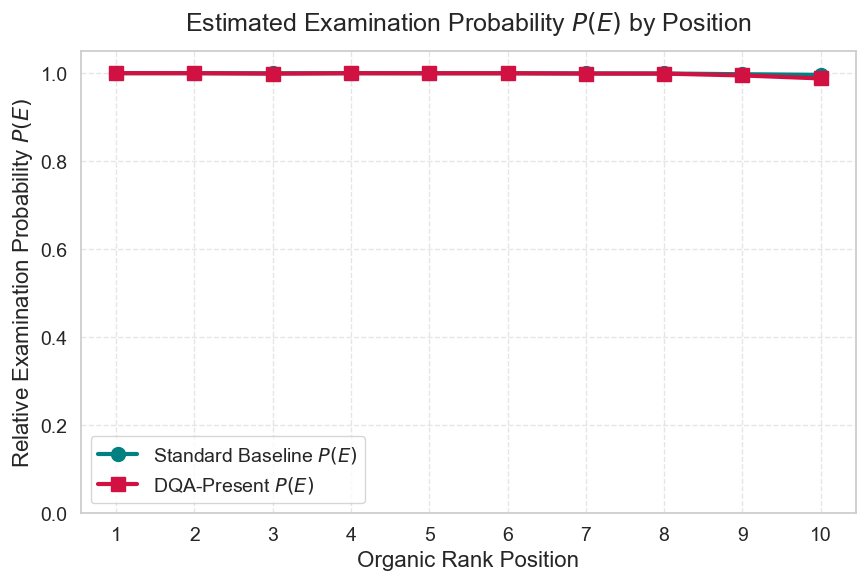

In [3]:
plt.figure(figsize=(10, 6))

# Plot Standard Baseline
plt.plot(base_pbm['position'], base_pbm['examination_prob'], 
         marker='o', markersize=10, linewidth=3, color='#008080', label='Standard Baseline $P(E)$')

# Plot DQA-Present
plt.plot(dqa_pbm['position'], dqa_pbm['examination_prob'], 
         marker='s', markersize=10, linewidth=3, color='#D11141', label='DQA-Present $P(E)$')

# Formatting
plt.title('Estimated Examination Probability $P(E)$ by Position', pad=15, fontsize=18)
plt.xlabel('Organic Rank Position', fontsize=16)
plt.ylabel('Relative Examination Probability $P(E)$', fontsize=16)

plt.xticks(range(1, 11), fontsize=14)
plt.yticks(fontsize=14)

plt.ylim(0, 1.05)
plt.legend(fontsize=14)

plt.grid(True, linestyle='--', alpha=0.5)

plt.savefig('Fig_3 pbm_examination_curves_sq2.pdf', format='pdf', bbox_inches='tight')
plt.show()

### 3. Exporting Bias Parameters
These calculated examination probabilities act as the empirical proof of layout bias. We can export these to use as comparative weights or initialization parameters for our downstream Neural Network (PAL model) in SQ3.

In [4]:
# Create a comparative dataframe
comparison_df = pd.merge(
    base_pbm[['position', 'examination_prob']], 
    dqa_pbm[['position', 'examination_prob']], 
    on='position', 
    suffixes=('_Standard', '_DQA')
)

comparison_df['Absolute_Difference'] = comparison_df['examination_prob_Standard'] - comparison_df['examination_prob_DQA']
comparison_df['Relative_Drop_Pct'] = (comparison_df['Absolute_Difference'] / comparison_df['examination_prob_Standard']) * 100

print("Examination Probability Comparison:")
display(comparison_df.round(4))

# Save the table
comparison_df.to_csv('sq2_pbm_parameters.csv', index=False)

Examination Probability Comparison:


,position,examination_prob_Standard,examination_prob_DQA,Absolute_Difference,Relative_Drop_Pct
0,1.0,1.0000,1.0000,0.0000,0.0000
1,2.0,1.0000,0.9999,0.0001,0.0075
2,3.0,0.9997,0.9989,0.0009,0.0876
3,4.0,1.0000,0.9998,0.0001,0.0130
4,5.0,0.9999,0.9997,0.0002,0.0219
5,6.0,0.9998,0.9997,0.0002,0.0186
6,7.0,0.9995,0.9990,0.0005,0.0498
7,8.0,0.9993,0.9989,0.0003,0.0349
8,9.0,0.9976,0.9948,0.0028,0.2806
9,10.0,0.9962,0.9880,0.0082,0.8207


In [5]:
import pandas as pd

# 1. Create the unique query-document identifier (if not already created)
base_imp['query_doc'] = base_imp['search_idx'].astype(str) + "_" + base_imp['note_idx'].astype(str)

# 2. Count how many times each unique pair appears
pair_frequencies = base_imp['query_doc'].value_counts()

# 3. Calculate the sparsity statistics
total_unique_pairs = len(pair_frequencies)
pairs_with_freq_1 = (pair_frequencies == 1).sum()
percentage_freq_1 = (pairs_with_freq_1 / total_unique_pairs) * 100

# 4. Print the "Mic Drop" proof
print(f"Total unique query-doc pairs: {total_unique_pairs:,}")
print(f"Pairs appearing exactly ONCE: {pairs_with_freq_1:,}")
print(f"Percentage of pairs appearing exactly once: {percentage_freq_1:.2f}%\n")

# 5. Look at the absolute maximum frequency just to be sure
print("Top 5 most frequent query-doc pairs in the dataset:")
print(pair_frequencies.head(5))

Total unique query-doc pairs: 1,029,189
Pairs appearing exactly ONCE: 1,029,078
Percentage of pairs appearing exactly once: 99.99%

Top 5 most frequent query-doc pairs in the dataset:
query_doc
20814_1109798    2
20814_120739     2
20814_317991     2
20814_1282832    2
20814_1855047    2
Name: count, dtype: int64
